In [20]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.regression.linear_model import yule_walker
from statsmodels.tsa.stattools import adfuller,acf
from statsmodels.tsa.arima.model import ARIMA
from  pandas.tseries.offsets import DateOffset
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from  pandas.tseries.offsets import DateOffset
import warnings
warnings.filterwarnings('ignore')
import seaborn as sms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [55]:
missing_values=["na","-"]
bokhol=pd.read_excel('basedonnees.xlsx',na_values=missing_values,index_col=[0],parse_dates=True)

In [56]:
bokhol.describe(include="all")

,W2- Irradiance (W/m²),W3 - Irradiance (W/m²),W4 - Irradiance (W/m²),Temperature ambiante (°C),Vitesse du vent (m/s),Température module (°C),Production Centrale Meter 1 - (W)
count,105069.000000,105061.0,105062.000000,105074.000000,105077.000000,104872.000000,1.045020e+05
unique,NaN,41892.0,NaN,NaN,NaN,NaN,NaN
top,NaN,0.0,NaN,NaN,NaN,NaN,NaN
freq,NaN,51572.0,NaN,NaN,NaN,NaN,NaN
mean,260.276651,NaN,259.809913,29.451952,2.900866,33.731880,4.486998e+06
std,347.886417,NaN,347.724505,5.162296,1.470228,6.458327,6.034425e+06
min,0.000000,NaN,0.000000,13.735000,0.000000,0.000000,0.000000e+00
25%,0.000000,NaN,0.000000,26.181775,1.700000,29.100000,0.000000e+00
50%,3.850000,NaN,3.525000,29.260000,2.835400,31.600000,1.356000e+05
75%,535.130000,NaN,532.142500,33.001700,3.883300,38.700000,9.030000e+06


In [57]:
bokhol.isnull().sum()

W2- Irradiance (W/m²)                 50
W3 - Irradiance (W/m²)                58
W4 - Irradiance (W/m²)                57
 Temperature ambiante (°C)            45
 Vitesse du vent (m/s)                42
Température module (°C)              247
Production Centrale Meter 1 - (W)    617
dtype: int64

In [58]:
bokhol=bokhol.dropna(axis=0)

In [59]:
bokhol.isnull().sum()

W2- Irradiance (W/m²)                0
W3 - Irradiance (W/m²)               0
W4 - Irradiance (W/m²)               0
 Temperature ambiante (°C)           0
 Vitesse du vent (m/s)               0
Température module (°C)              0
Production Centrale Meter 1 - (W)    0
dtype: int64

In [60]:
bokhol.rename(columns={
    'W2- Irradiance (W/m²)': 'Irradiance_W2',
    'W3 - Irradiance (W/m²)': 'Irradiance_W3',
    'W4 - Irradiance (W/m²)': 'Irradiance_W4',
    ' Temperature ambiante (°C)': 'Ambient_Temperature',
    ' Vitesse du vent (m/s)': 'Wind_Speed',
    'Température module (°C)': 'Module_Temperature',
    'Production Centrale Meter 1 - (W)': 'Plant_Production'
}, inplace=True) 

In [61]:
bokhol.head()

,Irradiance_W2,Irradiance_W3,Irradiance_W4,Ambient_Temperature,Wind_Speed,Module_Temperature,Plant_Production
Date (+00:00),,,,,,,
2021-01-01 00:05:00,0.0,0,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:10:00,0.0,0,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:15:00,0.0,0,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:20:00,0.0,0,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:25:00,0.0,0,0.0,21.9667,1.7416,25.9,0.0


In [62]:
bokhol= bokhol.drop(['Irradiance_W3','Irradiance_W4'],axis=1)
bokhol.head()

,Irradiance_W2,Ambient_Temperature,Wind_Speed,Module_Temperature,Plant_Production
Date (+00:00),,,,,
2021-01-01 00:05:00,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:10:00,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:15:00,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:20:00,0.0,21.9667,1.7416,25.9,0.0
2021-01-01 00:25:00,0.0,21.9667,1.7416,25.9,0.0


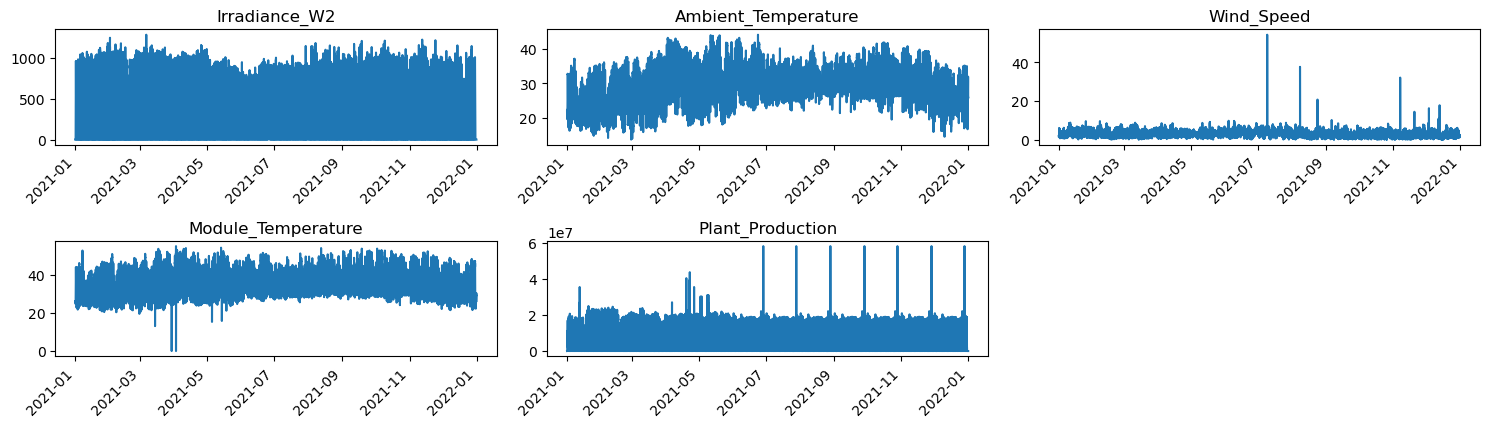

In [63]:
variable = list(bokhol.columns)

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(variable):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(bokhol[j])
    ax.set_title(f"{j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

#plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

### Irradiation 

In [64]:
irradiation = bokhol[[bokhol.columns[0]]]
irradiation.head()

,Irradiance_W2
Date (+00:00),
2021-01-01 00:05:00,0.0
2021-01-01 00:10:00,0.0
2021-01-01 00:15:00,0.0
2021-01-01 00:20:00,0.0
2021-01-01 00:25:00,0.0


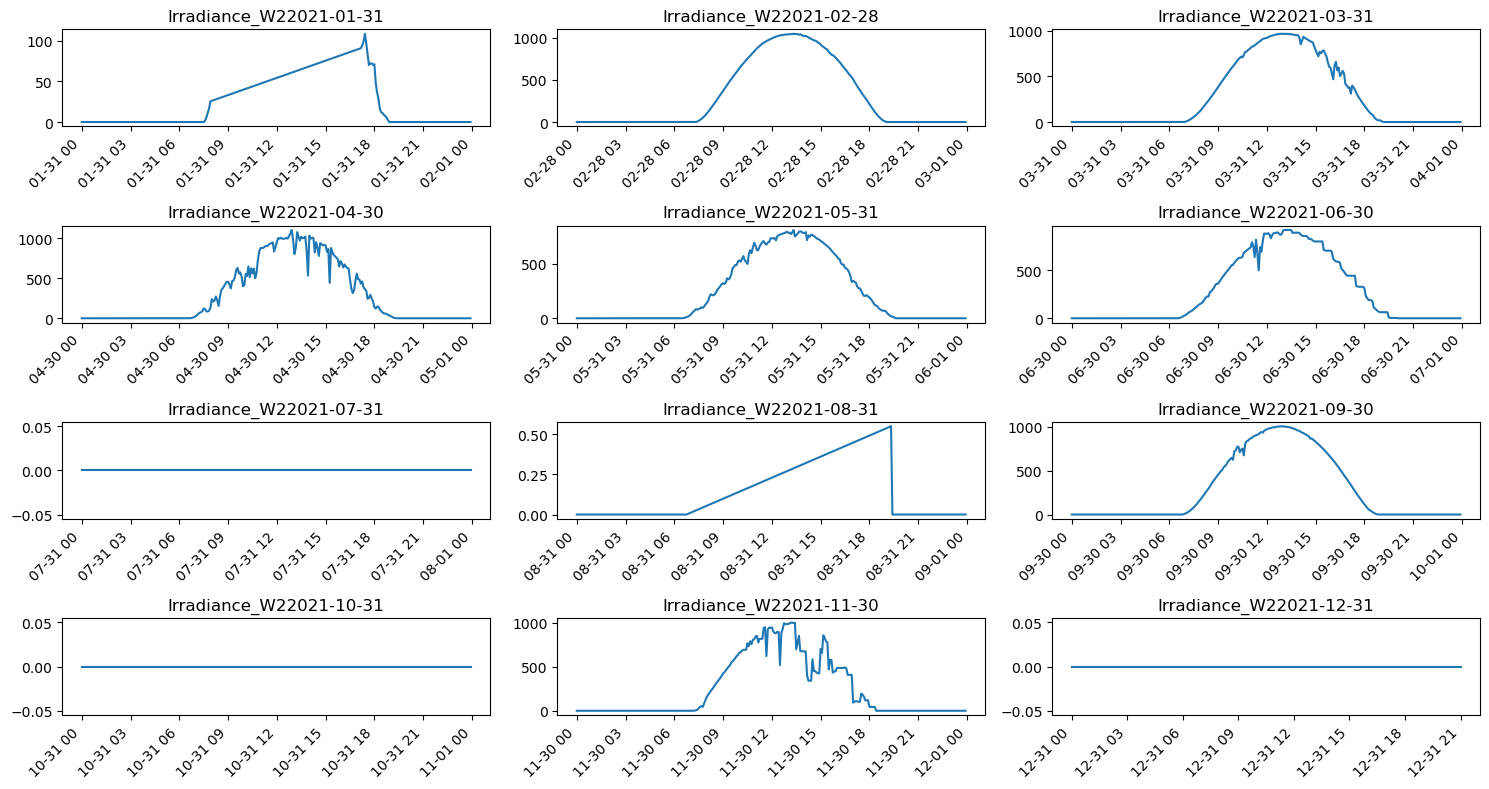

In [65]:
list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(irradiation.loc[j])
    ax.set_title(f"Irradiance_W2{j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

#plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

### temperature

In [68]:
temperature_ambiante = bokhol[[bokhol.columns[1]]]
temperature_ambiante.head()

,Ambient_Temperature
Date (+00:00),
2021-01-01 00:05:00,21.9667
2021-01-01 00:10:00,21.9667
2021-01-01 00:15:00,21.9667
2021-01-01 00:20:00,21.9667
2021-01-01 00:25:00,21.9667


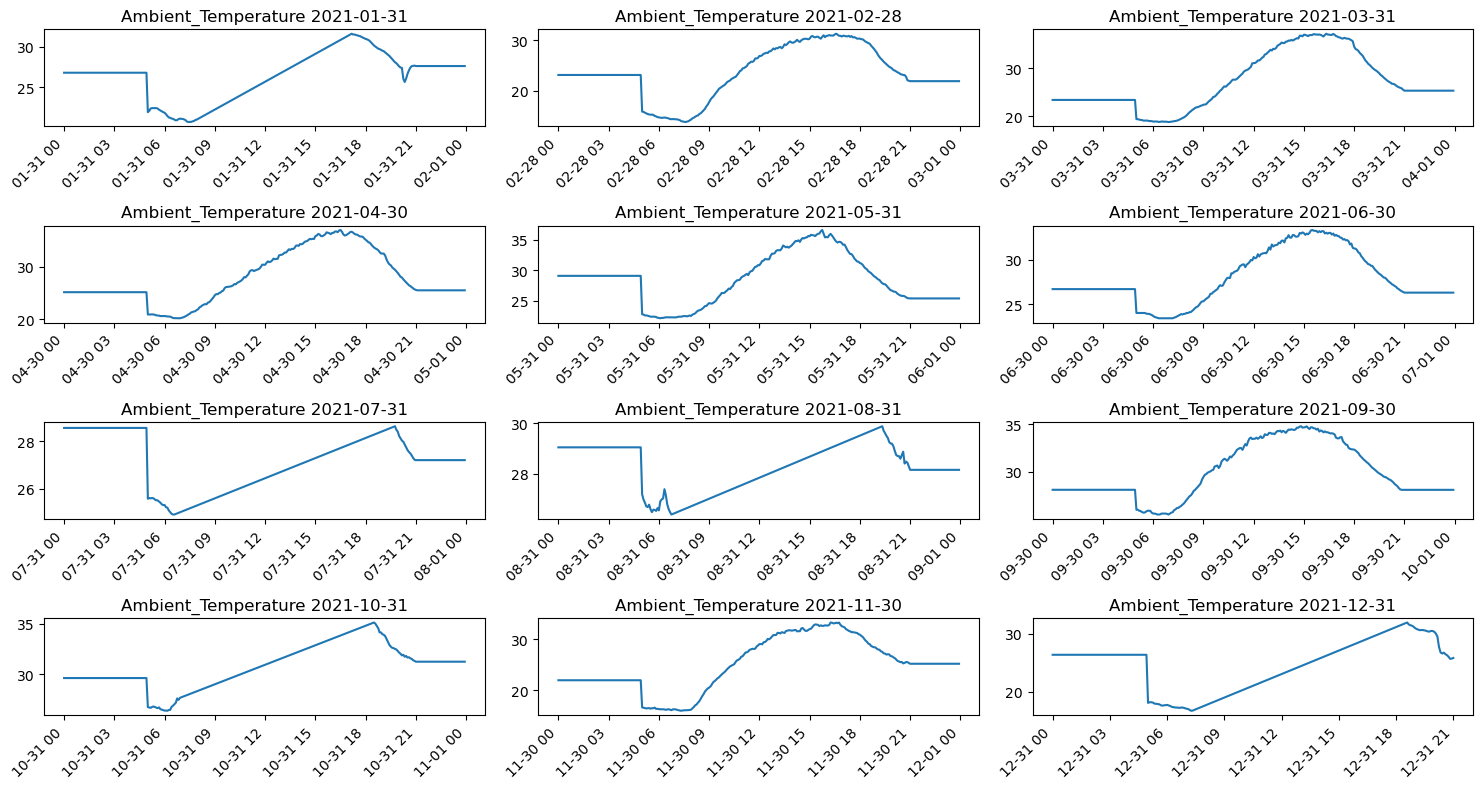

In [69]:
list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(temperature_ambiante.loc[j])
    ax.set_title(f"Ambient_Temperature {j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

#plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

### vitesse du vent

In [70]:
Vitesse_du_vent = bokhol[[bokhol.columns[2]]]
Vitesse_du_vent.head()

,Wind_Speed
Date (+00:00),
2021-01-01 00:05:00,1.7416
2021-01-01 00:10:00,1.7416
2021-01-01 00:15:00,1.7416
2021-01-01 00:20:00,1.7416
2021-01-01 00:25:00,1.7416


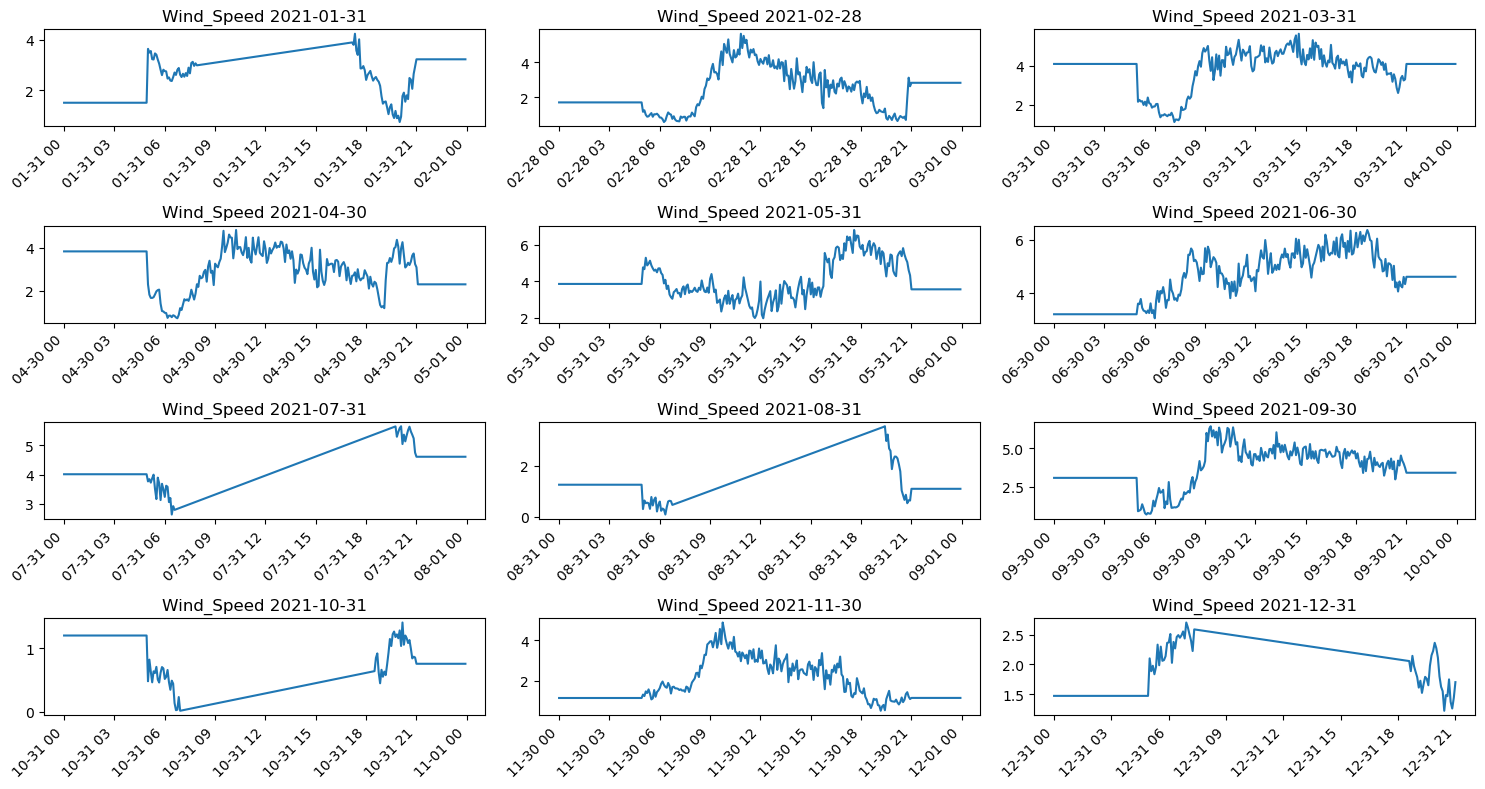

In [71]:
list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(Vitesse_du_vent.loc[j])
    ax.set_title(f"Wind_Speed {j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

#plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

### temperature du module PV

In [72]:
temperature_module = bokhol[[bokhol.columns[3]]]
temperature_module.head()

,Module_Temperature
Date (+00:00),
2021-01-01 00:05:00,25.9
2021-01-01 00:10:00,25.9
2021-01-01 00:15:00,25.9
2021-01-01 00:20:00,25.9
2021-01-01 00:25:00,25.9


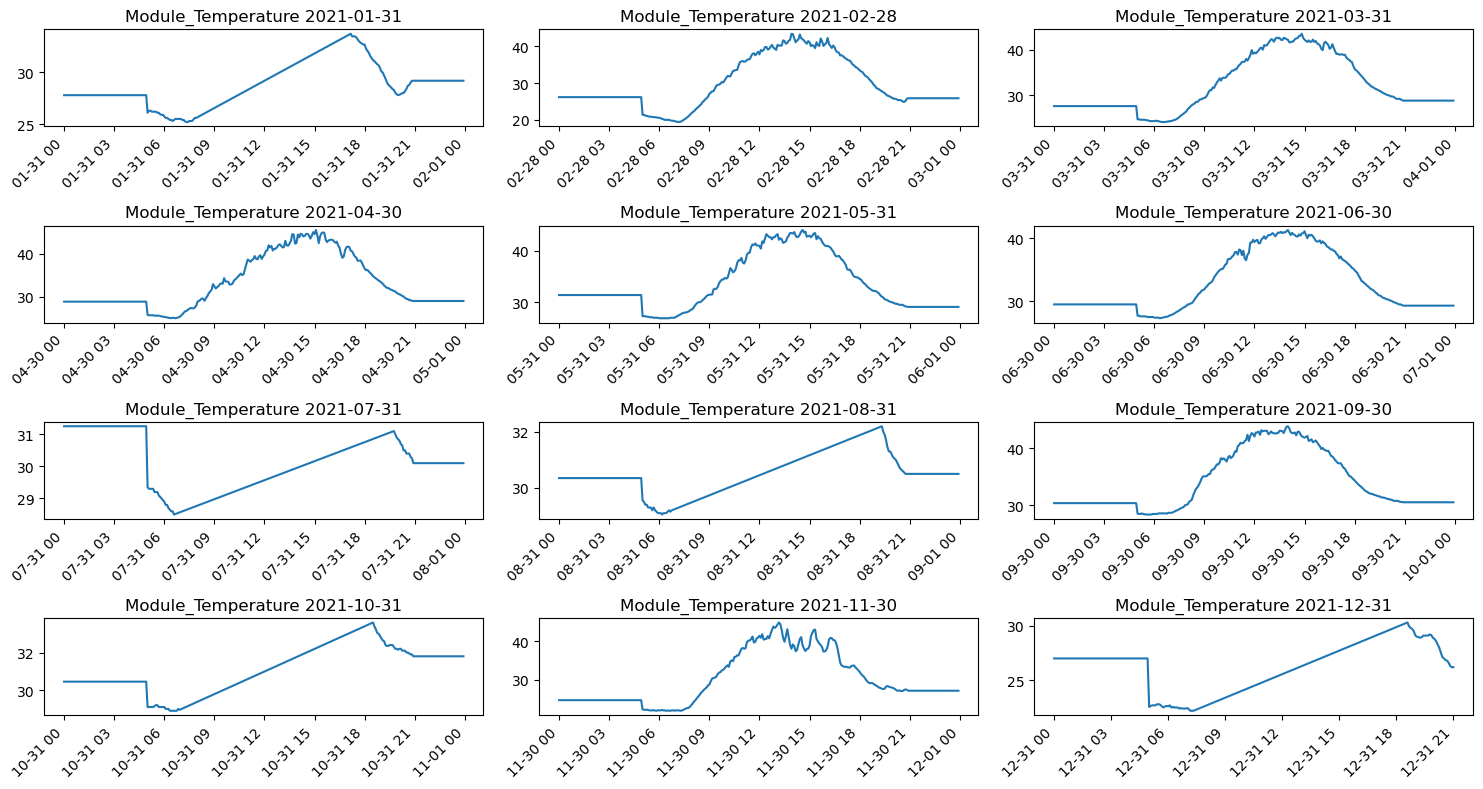

In [73]:
list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(temperature_module.loc[j])
    ax.set_title(f"Module_Temperature {j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

#plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

### Production

In [76]:
production = bokhol[[bokhol.columns[4]]]
production.head()

,Plant_Production
Date (+00:00),
2021-01-01 00:05:00,0.0
2021-01-01 00:10:00,0.0
2021-01-01 00:15:00,0.0
2021-01-01 00:20:00,0.0
2021-01-01 00:25:00,0.0


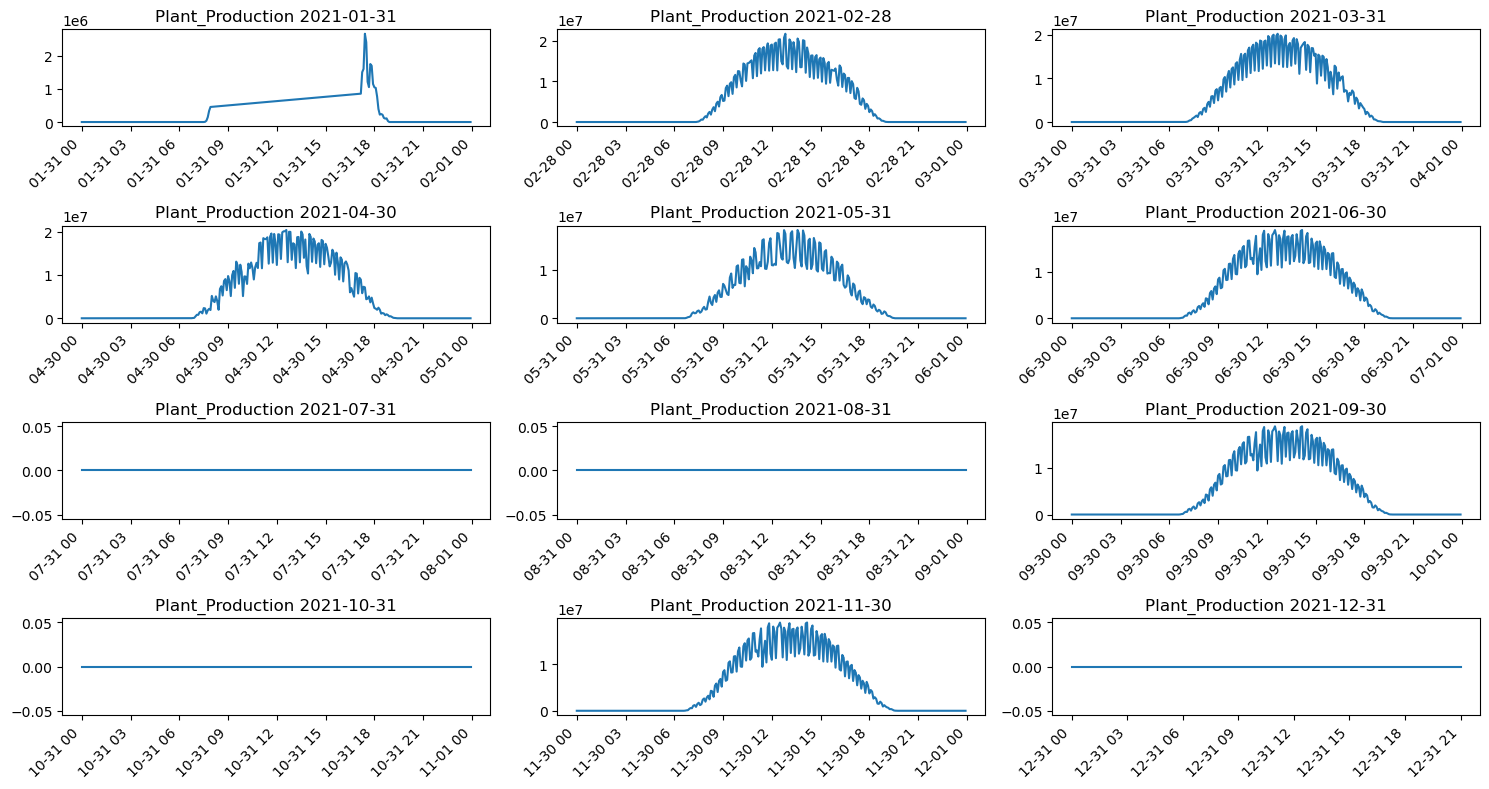

In [77]:
list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(4,3,1+i)
    ax.plot(production.loc[j])
    ax.set_title(f"Plant_Production {j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.savefig('production_annuel.png')
plt.tight_layout()
plt.show()

In [10]:
from pmdarima import auto_arima
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

#orderModel1=auto_arima(production,trace=True,supress_warnings=True)

MODELES ARIMA AVEC DIVISION DE LA BASE DE DONNEES

In [79]:
puissance_train=production.iloc[:-365]
puissance_test=production.iloc[-365:]
model = sm.tsa.ARIMA(puissance_train, order=(5,0,4))
model_fit=model.fit()

VALIDATION DU MODELES

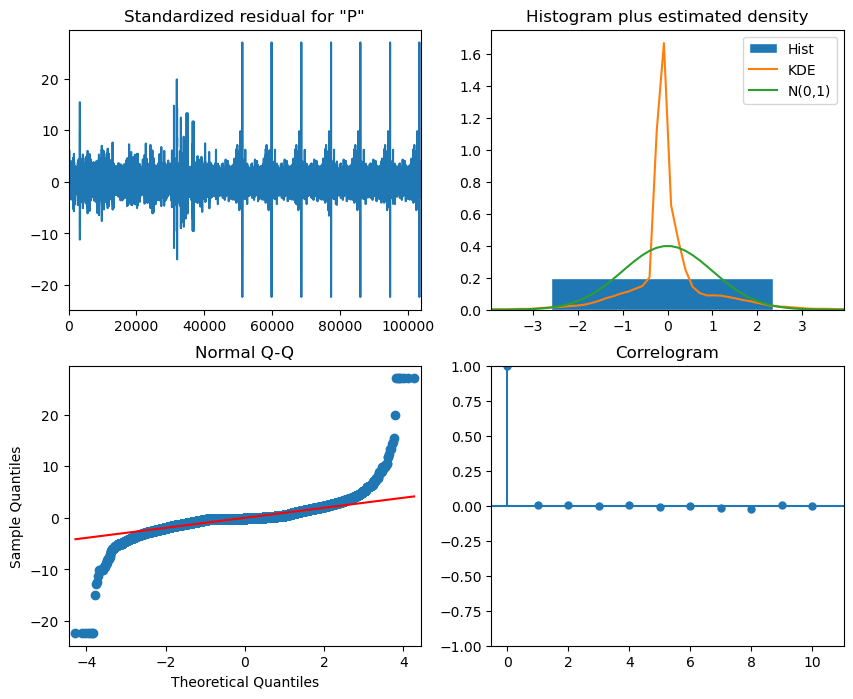

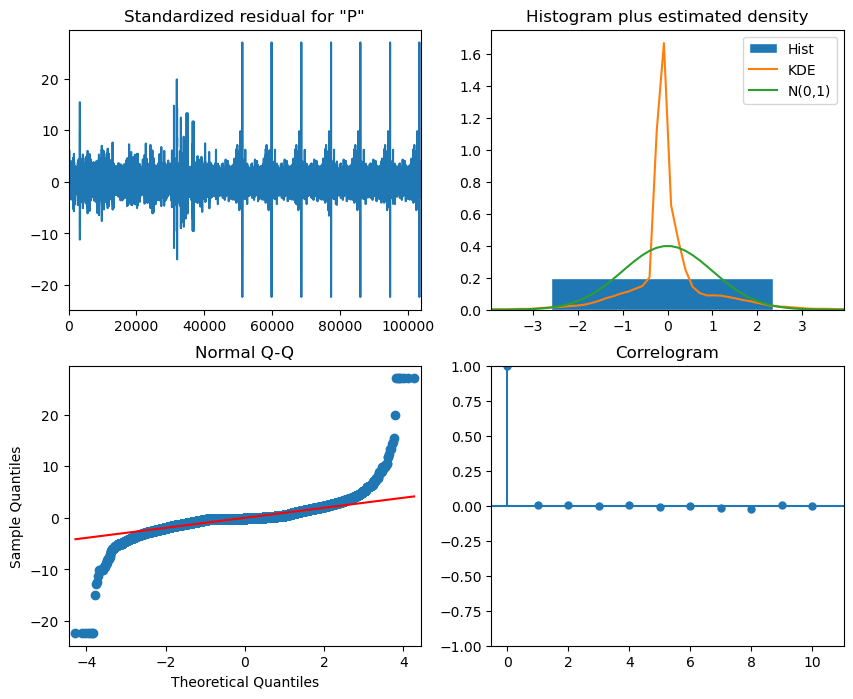

In [80]:
model_fit.plot_diagnostics(figsize=(10, 8))

ESTIMATION DE LA PRODUCTION DANS L'ECHANTIOLLION DE MESURES

In [81]:
model=ARIMA(puissance_train,order=(5,0,4))
model_fit=model.fit()

In [82]:
puissance_test.shape[0]

365

<Figure size 1500x700 with 0 Axes>

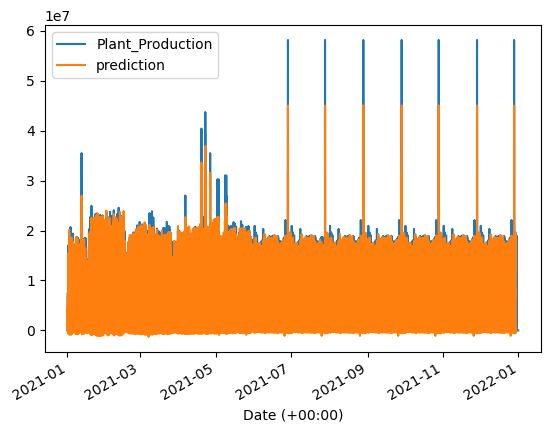

In [90]:
production['prediction']=model_fit.predict()
plt.figure(figsize=(15,7))
production.plot()
plt.legend()
#plt.savefig(prediction)

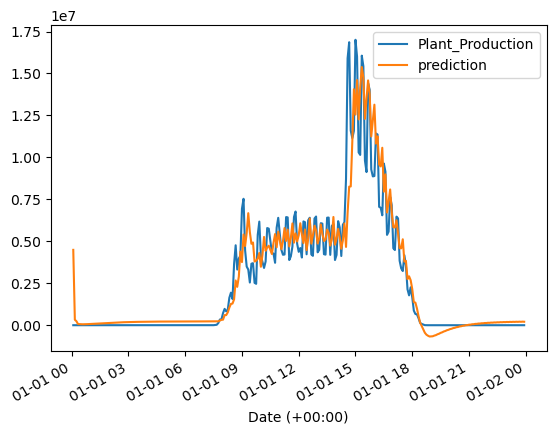

In [93]:
production.loc['2021-01-01'].plot()

plt.savefig('production_jenvier.png')

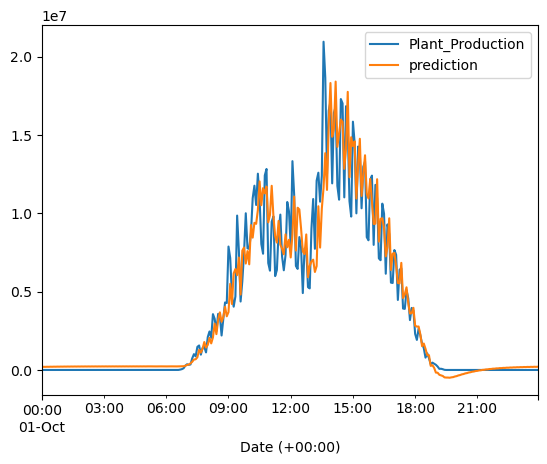

In [94]:
production.loc['2021-10-01'].plot()
plt.savefig('production_octobre.png')

In [95]:
mois=np.array(pd.date_range(production.index[0],freq='M',periods=12))

mois

array(['2021-01-31T00:05:00.000000000', '2021-02-28T00:05:00.000000000',
       '2021-03-31T00:05:00.000000000', '2021-04-30T00:05:00.000000000',
       '2021-05-31T00:05:00.000000000', '2021-06-30T00:05:00.000000000',
       '2021-07-31T00:05:00.000000000', '2021-08-31T00:05:00.000000000',
       '2021-09-30T00:05:00.000000000', '2021-10-31T00:05:00.000000000',
       '2021-11-30T00:05:00.000000000', '2021-12-31T00:05:00.000000000'],
      dtype='datetime64[ns]')

list_mois=['2021-01-31','2021-02-28',
       '2021-03-31', '2021-04-30',
       '2021-05-31', '2021-06-30',
       '2021-07-31', '2021-08-31',
       '2021-09-30', '2021-10-31',
       '2021-11-30', '2021-12-31']

In [100]:
production.head()

,Plant_Production,prediction
Date (+00:00),,
2021-01-01 00:05:00,0.0,4.490234e+06
2021-01-01 00:10:00,0.0,3.269744e+05
2021-01-01 00:15:00,0.0,2.387318e+05
2021-01-01 00:20:00,0.0,6.961219e+04
2021-01-01 00:25:00,0.0,6.399355e+04


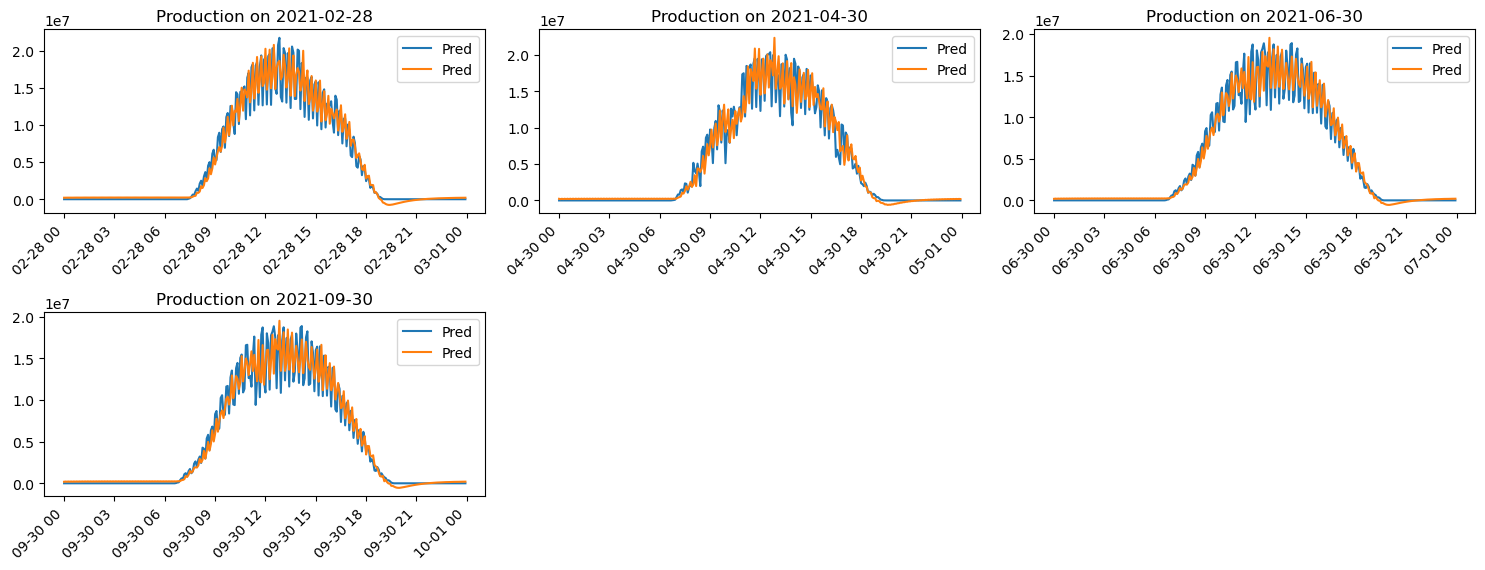

In [99]:
list_mois=['2021-02-28', 
           '2021-04-30', '2021-06-30',
           '2021-09-30']

fig=plt.figure(figsize=(15,8))
for i,j in enumerate(list_mois):
    
    ax=fig.add_subplot(3,3,1+i)
    ax.plot(production.loc[j],label='Pred')
    ax.set_title(f"Production on {j}")
    
    # ➤ Rotation des labels de l'axe x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend()


plt.tight_layout()
plt.show()